In [1]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
import warnings
import seaborn as sns
%matplotlib inline
warnings.filterwarnings('ignore')

In [2]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: []


In [3]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [4]:
import os

filepath = '/content/train_FD001.txt'

data_train = pd.read_csv(filepath, sep=" ", header=None)

data_test = pd.read_csv('/content/test_FD001.txt', sep=" ", header=None)
data_train

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,NaN,NaN
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,NaN,NaN
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,NaN,NaN
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,NaN,NaN
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,NaN,NaN
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,NaN,NaN
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,NaN,NaN


In [5]:
rul = pd.read_csv('RUL_FD001.txt', header=None, names=['RUL'])

print(f"Number of test engines: {len(rul)}")
print(rul.head())

Number of test engines: 100
   RUL
0  112
1   98
2   69
3   82
4   91


In [6]:
columns = ['unit_number','time_in_cycles','setting_1','setting_2','TRA','T2','T24','T30','T50','P2','P15','P30','Nf',
           'Nc','epr','Ps30','phi','NRf','NRc','BPR','farB','htBleed','Nf_dmd','PCNfR_dmd','W31','W32' ]

data_train = data_train.drop(data_train.columns[[26, 27]], axis=1)
data_test = data_test.drop(data_test.columns[[26,27]], axis = 1)

data_train.columns = columns
data_test.columns = columns


In [7]:
data_test.head()

,unit_number,time_in_cycles,setting_1,setting_2,TRA,T2,T24,T30,T50,P2,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [8]:
data_train.head()

,unit_number,time_in_cycles,setting_1,setting_2,TRA,T2,T24,T30,T50,P2,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [9]:
print(f"Train shape : {data_train.shape}")
print(f"Test  shape : {data_test.shape}")
print(f"RUL labels  : {rul.shape}")

Train shape : (20631, 26)
Test  shape : (13096, 26)
RUL labels  : (100, 1)


# Print the constant values


In [10]:
constant_features = [col for col in data_train.columns if data_train[col].nunique() <= 1]

print(f'Dead/Constant Sensors identified: {constant_features}')
print(f'Number of Dead Sensors: {len(constant_features)} sensors.')

Dead/Constant Sensors identified: ['TRA', 'T2', 'P2', 'epr', 'farB', 'Nf_dmd', 'PCNfR_dmd']
Number of Dead Sensors: 7 sensors.


In [11]:
data_train.drop(columns=constant_features, inplace=True)
data_test.drop(columns=constant_features, inplace=True)

In [12]:
data_train.columns

Index(['unit_number', 'time_in_cycles', 'setting_1', 'setting_2', 'T24', 'T30',
       'T50', 'P15', 'P30', 'Nf', 'Nc', 'Ps30', 'phi', 'NRf', 'NRc', 'BPR',
       'htBleed', 'W31', 'W32'],
      dtype='object')

In [13]:
feature_cols = [col for col in data_train.columns]
feature_cols

['unit_number',
 'time_in_cycles',
 'setting_1',
 'setting_2',
 'T24',
 'T30',
 'T50',
 'P15',
 'P30',
 'Nf',
 'Nc',
 'Ps30',
 'phi',
 'NRf',
 'NRc',
 'BPR',
 'htBleed',
 'W31',
 'W32']

In [14]:
data_train.head()

,unit_number,time_in_cycles,setting_1,setting_2,T24,T30,T50,P15,P30,Nf,Nc,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044


In [15]:
data_test.head()

,unit_number,time_in_cycles,setting_1,setting_2,T24,T30,T50,P15,P30,Nf,Nc,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32
0,1,1,0.0023,0.0003,643.02,1585.29,1398.21,21.61,553.90,2388.04,9050.17,47.20,521.72,2388.03,8125.55,8.4052,392,38.86,23.3735
1,1,2,-0.0027,-0.0003,641.71,1588.45,1395.42,21.61,554.85,2388.01,9054.42,47.50,522.16,2388.06,8139.62,8.3803,393,39.02,23.3916
2,1,3,0.0003,0.0001,642.46,1586.94,1401.34,21.61,554.11,2388.05,9056.96,47.50,521.97,2388.03,8130.10,8.4441,393,39.08,23.4166
3,1,4,0.0042,0.0000,642.44,1584.12,1406.42,21.61,554.07,2388.03,9045.29,47.28,521.38,2388.05,8132.90,8.3917,391,39.00,23.3737
4,1,5,0.0014,0.0000,642.51,1587.19,1401.92,21.61,554.16,2388.01,9044.55,47.31,522.15,2388.03,8129.54,8.4031,390,38.99,23.4130


In [16]:
def add_RUL(data, factor = 0):
    df = data.copy()
    fd_RUL = df.groupby('unit_number')['time_in_cycles'].max().reset_index()
    fd_RUL = pd.DataFrame(fd_RUL)
    fd_RUL.columns = ['unit_number','max']
    df = df.merge(fd_RUL, on=['unit_number'], how='left')
    df['RUL'] = df['max'] - df['time_in_cycles']
    df.drop(columns=['max'],inplace = True)

    return df[df['time_in_cycles'] > factor]

In [17]:
data_train = add_RUL(data_train)

In [18]:
RUL_THRESHOLD = 125
data_train['RUL'] = data_train['RUL'].clip(upper=RUL_THRESHOLD)
print(f"RUL Clipping applied. Max RUL is now capped at {RUL_THRESHOLD} cycles.")

RUL Clipping applied. Max RUL is now capped at 125 cycles.


In [19]:
data_train.head()

,unit_number,time_in_cycles,setting_1,setting_2,T24,T30,T50,P15,P30,Nf,Nc,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,RUL
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,125
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,125
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,125
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,125
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,125


In [20]:
def get_last_cycle_per_engine(df_test, id_column='unit_number', time_column='time_in_cycles'):
    assert id_column in df_test.columns, f"Missing column: {id_column}"
    assert time_column in df_test.columns, f"Missing column: {time_column}"

    last_cycles = df_test.sort_values(by=[id_column, time_column]) \
                         .groupby(id_column) \
                         .tail(1) \
                         .reset_index(drop=True)

    return last_cycles

In [21]:
data_001_test_raw = data_test.copy()

last_cycles_raw = get_last_cycle_per_engine(data_001_test_raw)

last_cycles_raw.to_csv("last_cycles_per_engine.csv", index=False)

In [22]:
engine_lifespan = data_train.groupby('unit_number')['time_in_cycles'].max()

print("Mean Lifespan:", engine_lifespan.mean())
print("Min Lifespan:", engine_lifespan.min())
print("Max Lifespan:", engine_lifespan.max())

Mean Lifespan: 206.31
Min Lifespan: 128
Max Lifespan: 362


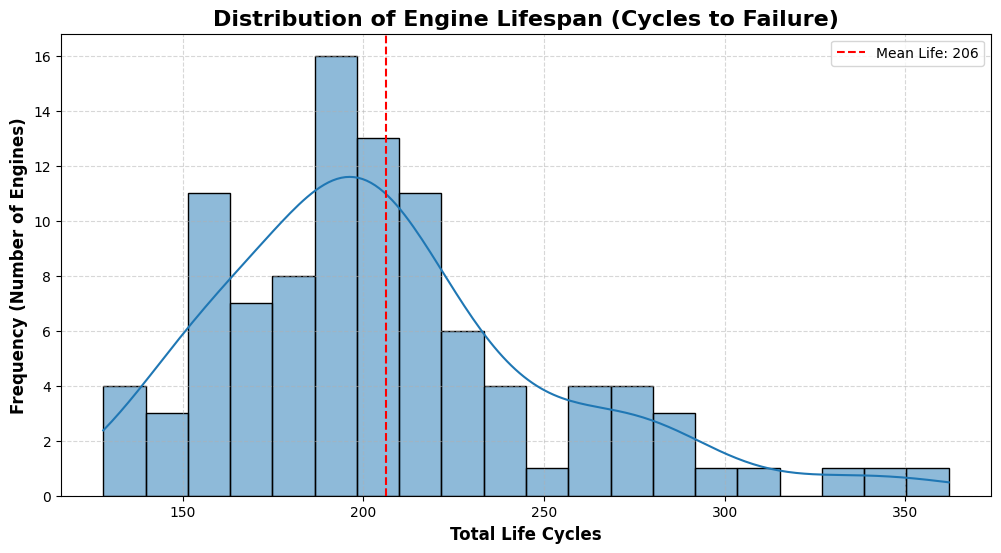

In [23]:
# Lifespan Distribution

plt.figure(figsize=(12, 6))
sns.histplot(engine_lifespan, kde=True, color='#1f77b4', bins=20)
plt.title('Distribution of Engine Lifespan (Cycles to Failure)', fontweight='bold', size=16)
plt.xlabel('Total Life Cycles', fontweight='bold', size=12)
plt.ylabel('Frequency (Number of Engines)', fontweight='bold', size=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axvline(engine_lifespan.mean(), color='r', linestyle='--', label=f'Mean Life: {int(engine_lifespan.mean())}')
plt.legend()
plt.show()

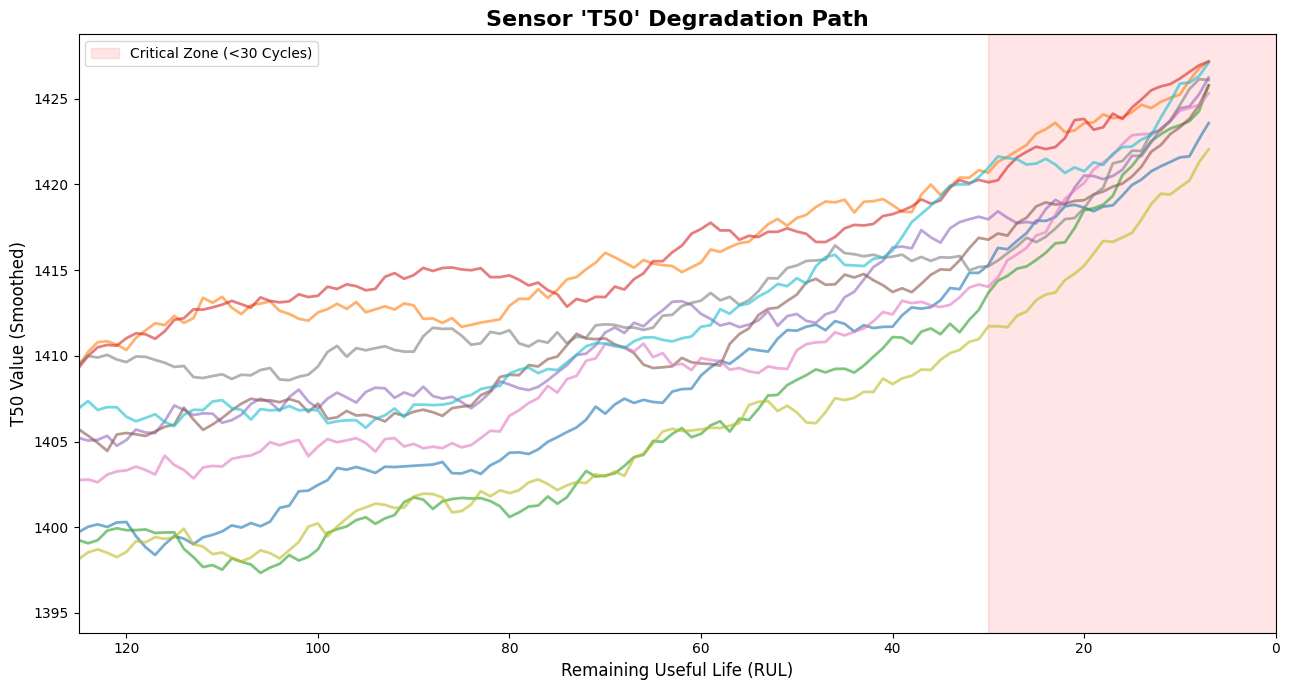

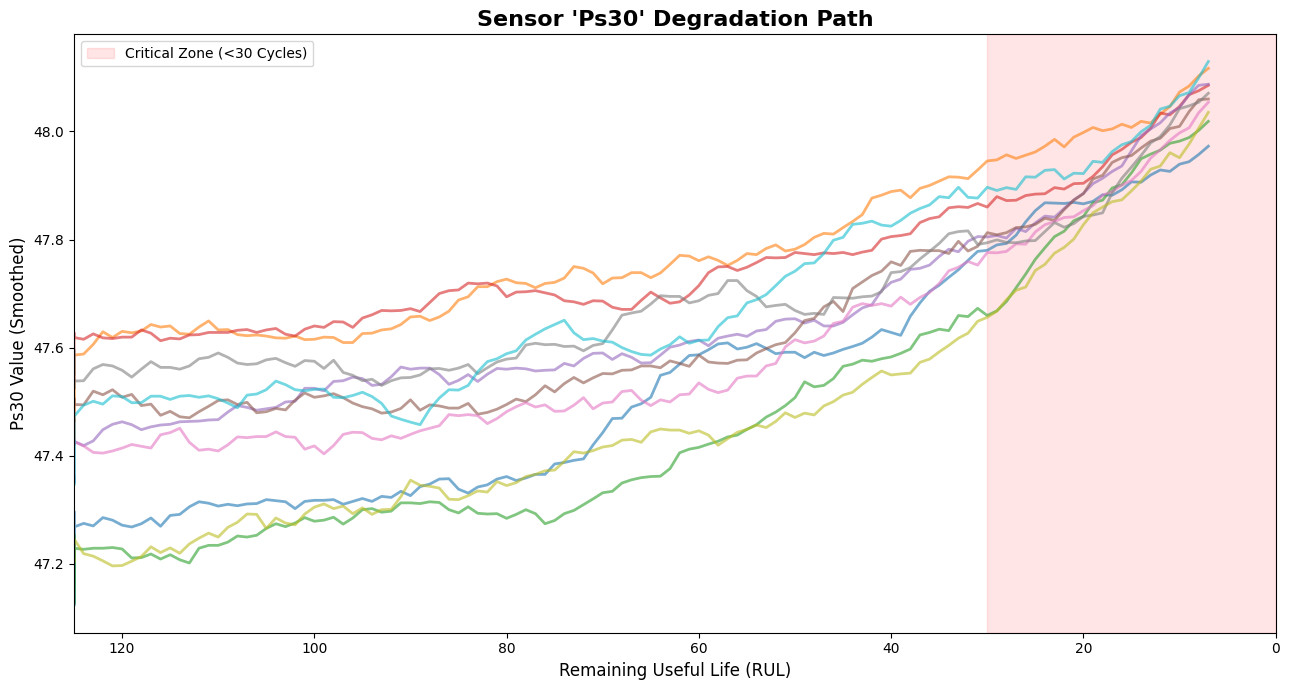

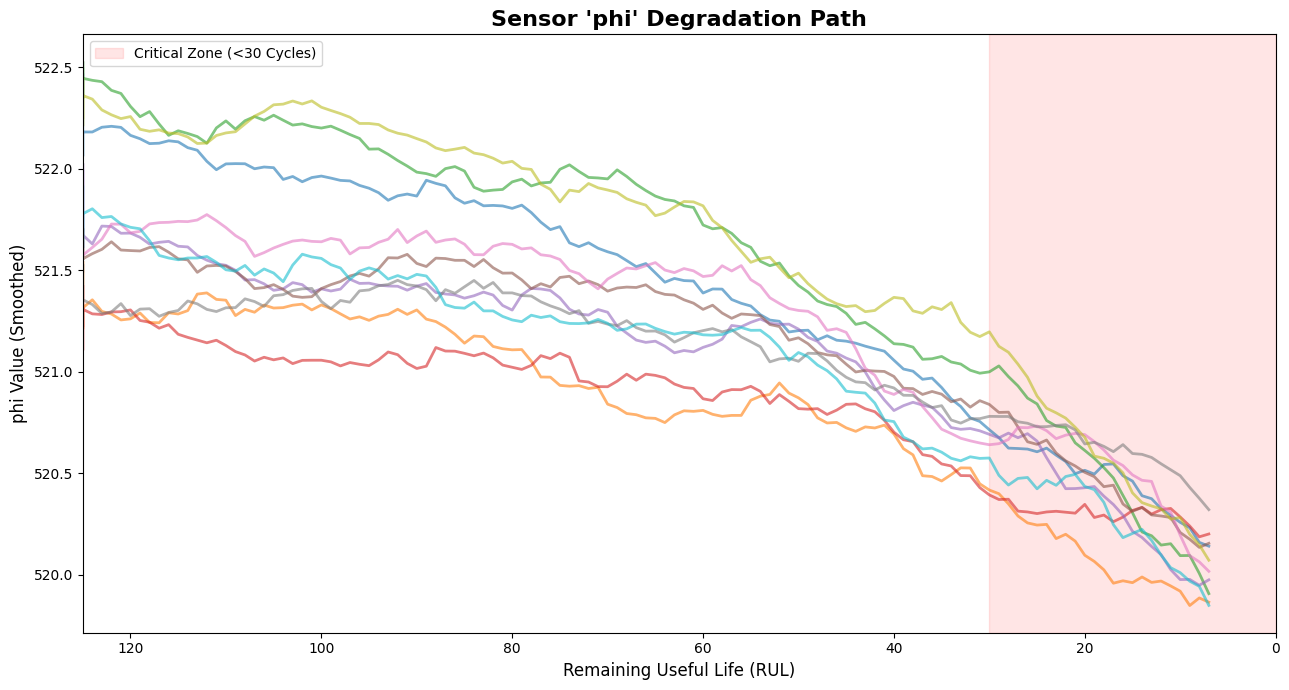

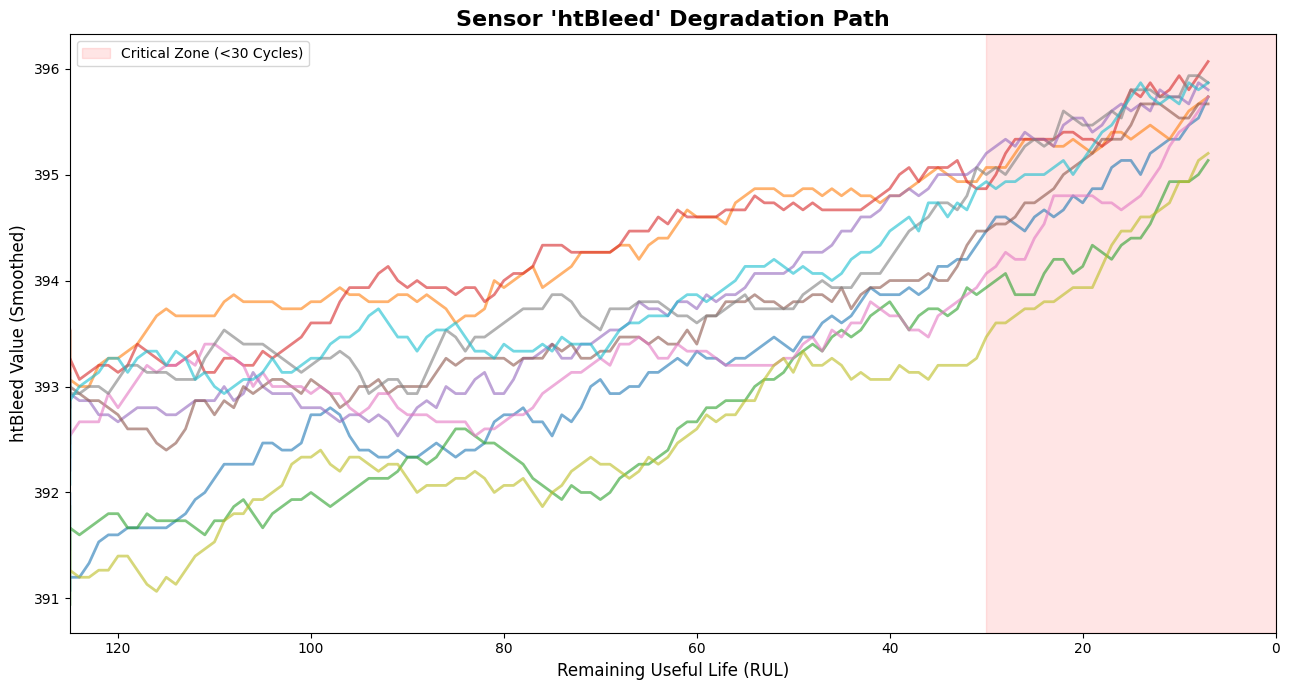

In [24]:
def plot_engine_evolution_v2(df, sensor_name):
    if sensor_name not in df.columns:
        return

    plt.figure(figsize=(13, 7))

    units_to_plot = [u for u in df['unit_number'].unique() if u % 10 == 0]

    for unit in units_to_plot:
        unit_data = df[df['unit_number'] == unit].sort_values('time_in_cycles')

        smoothed_signal = unit_data[sensor_name].rolling(window=15, center=True).mean()

        plt.plot(unit_data['RUL'], smoothed_signal, linewidth=2, alpha=0.6)

    plt.xlim(df['RUL'].max(), 0)
    plt.axvspan(30, 0, color='red', alpha=0.1, label='Critical Zone (<30 Cycles)')

    plt.title(f"Sensor '{sensor_name}' Degradation Path", fontsize=16, fontweight='bold')
    plt.xlabel('Remaining Useful Life (RUL)', fontsize=12)
    plt.ylabel(f'{sensor_name} Value (Smoothed)', fontsize=12)
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

desired_sensors = ['T50', 'Ps30', 'phi', 'htBleed']
valid_sensors_to_plot = [s for s in desired_sensors if s in data_train.columns]

for sensor in valid_sensors_to_plot:
    plot_engine_evolution_v2(data_train, sensor)

In [25]:
features_to_normalize = [col for col in data_train.columns if col not in ['unit_number', 'time_cycles', 'RUL']]
scaler = MinMaxScaler()
data_train[features_to_normalize] = scaler.fit_transform(data_train[features_to_normalize])
data_test[features_to_normalize] = scaler.transform(data_test[features_to_normalize])


print("\nScaling completed successfully.")
print(f"Features Scaled: {len(features_to_normalize)}")

print("Data Scaling Completed (Range 0-1).")
print('\nData Preview after Scaling (Train) :\n')
display(data_train.head())

print('\nCheck Min/Max values (Should be 0 and 1) :\n')
display(data_train[features_to_normalize].describe().loc[['min', 'max']])


Scaling completed successfully.
Features Scaled: 18
Data Scaling Completed (Range 0-1).

Data Preview after Scaling (Train) :



,unit_number,time_in_cycles,setting_1,setting_2,T24,T30,T50,P15,P30,Nf,Nc,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,RUL
0,1,0.00000,0.459770,0.166667,0.183735,0.406802,0.309757,1.0,0.726248,0.242424,0.109755,0.369048,0.633262,0.205882,0.199608,0.363986,0.333333,0.713178,0.724662,125
1,1,0.00277,0.609195,0.250000,0.283133,0.453019,0.352633,1.0,0.628019,0.212121,0.100242,0.380952,0.765458,0.279412,0.162813,0.411312,0.333333,0.666667,0.731014,125
2,1,0.00554,0.252874,0.750000,0.343373,0.369523,0.370527,1.0,0.710145,0.272727,0.140043,0.250000,0.795309,0.220588,0.171793,0.357445,0.166667,0.627907,0.621375,125
3,1,0.00831,0.540230,0.500000,0.343373,0.256159,0.331195,1.0,0.740741,0.318182,0.124518,0.166667,0.889126,0.294118,0.174889,0.166603,0.333333,0.573643,0.662386,125
4,1,0.01108,0.390805,0.333333,0.349398,0.257467,0.404625,1.0,0.668277,0.242424,0.149960,0.255952,0.746269,0.235294,0.174734,0.402078,0.416667,0.589147,0.704502,125



Check Min/Max values (Should be 0 and 1) :



,time_in_cycles,setting_1,setting_2,T24,T30,T50,P15,P30,Nf,Nc,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [26]:
X_train = data_train[features_to_normalize]
y_train = data_train['RUL']

X_test_last_cycle = data_test.groupby('unit_number').last().reset_index()
X_test = X_test_last_cycle[features_to_normalize]
y_true = rul['RUL']

print(f"Training Data: X={X_train.shape}, y={y_train.shape}")
print(f"Testing Data:  X={X_test.shape},  y={y_true.shape}")

assert X_test.shape[0] == y_true.shape[0], "Error: Mismatch in Test Data dimensions!"

Training Data: X=(20631, 18), y=(20631,)
Testing Data:  X=(100, 18),  y=(100,)


In [27]:
results_summary = []

## Grid Search CV = Cross ***Validation***

In [28]:
from sklearn.model_selection import GridSearchCV, KFold

In [29]:
def evaluate_model_cv(model, X_train, y_train, X_test, y_true, model_name):
    """
    Standardized evaluation function:
    """


    from sklearn.model_selection import train_test_split

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train,
        test_size=0.2,
        random_state=42
    )


    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)

    results_summary.append({
        'Model': model_name,
        'RMSE': rmse,
        'MAE': mae,
        'R2 Score': r2
    })


    errors = y_pred - y_true
    over_estimates = errors[errors > 0]
    num_over = len(over_estimates)
    total_samples = len(y_true)

    avg_over_est = np.mean(over_estimates) if num_over > 0 else 0
    pct_over_est = (num_over / total_samples) * 100

    under_estimates = errors[errors < 0]
    avg_under_est = np.mean(under_estimates) if len(under_estimates) > 0 else 0


    print(f"{model_name} Results")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE:  {mae:.2f}")
    print(f"R2:   {r2:.2%}")

    print("\n Risk Analysis (Bias)")
    print(f"Percentage of Over-estimates: {pct_over_est:.2f}%")
    print(f"Average Over-estimate Error:  +{avg_over_est:.2f} cycles")
    print(f"Average Under-estimate Error: {avg_under_est:.2f} cycles")


    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(y_true.values, label='Actual RUL', linestyle='--')
    plt.plot(y_pred, label=f'Predicted ({model_name})')
    plt.xlabel('Test Units Index')
    plt.ylabel('Remaining Useful Life (RUL)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Scatter plot
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred)

    min_val = min(min(y_true), min(y_pred))
    max_val = max(max(y_true), max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val])

    plt.xlabel("Actual RUL")
    plt.ylabel("Predicted RUL")
    plt.title("Actual vs Predicted RUL")

    plt.grid(True)
    plt.show()

    return y_pred

In [30]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0]
}

In [31]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42
)

In [32]:
from sklearn.model_selection import RandomizedSearchCV, KFold
from xgboost import XGBRegressor
import numpy as np

xgb = XGBRegressor(tree_method='hist', n_jobs=-1, random_state=42)

param_dist = {
    'n_estimators': np.arange(100, 400, 50),
    'learning_rate': np.linspace(0.01, 0.2, 10),
    'max_depth': [3, 4, 5, 6],
    'subsample': np.linspace(0.7, 1.0, 4),
    'colsample_bytree': np.linspace(0.7, 1.0, 4),
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10]
}

kf = KFold(n_splits=3, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=kf,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=KFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=Non...
                   param_distributions={'colsample_bytree': array([0.7, 0.8, 0.9, 1. ]),
                                        'learning_rate': array([0.01      , 0.03111111, 0.05222222, 0.07333333, 0.09444444,
       0.11555556, 0.13666667, 0.15777778, 0.17888889, 0.2       ]),
                                        'max_depth': [3, 4, 5, 6],
                                        'n_estimators': array([100, 150, 200, 250, 300, 350]),
                                        'reg_alpha': [0, 0.1, 1],
                                        'reg_lambda': [1, 5, 10],
                                        'subsample': array([0.7, 0.8, 0.9, 1. ])},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=2)

In [33]:
print("Best Params:", random_search.best_params_)
print("Best CV RMSE:", -random_search.best_score_)

Best Params: {'subsample': np.float64(0.7999999999999999), 'reg_lambda': 5, 'reg_alpha': 1, 'n_estimators': np.int64(300), 'max_depth': 6, 'learning_rate': np.float64(0.03111111111111111), 'colsample_bytree': np.float64(0.7)}
Best CV RMSE: 15.60872745513916


In [34]:
best_model = random_search.best_estimator_

In [35]:
best_model = random_search.best_estimator_

best_model.set_params(
    n_estimators=1000,
    early_stopping_rounds=20
)

best_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=np.float64(0.7), device=None,
             early_stopping_rounds=20, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None,
             learning_rate=np.float64(0.03111111111111111), max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=-1,
             num_parallel_tree=None, ...)

In [36]:
print("Best iteration:", best_model.best_iteration)

Best iteration: 266


Final Tuned XGBoost Results
RMSE: 18.41
MAE:  13.80
R2:   80.37%

 Risk Analysis (Bias)
Percentage of Over-estimates: 50.00%
Average Over-estimate Error:  +13.07 cycles
Average Under-estimate Error: -14.53 cycles


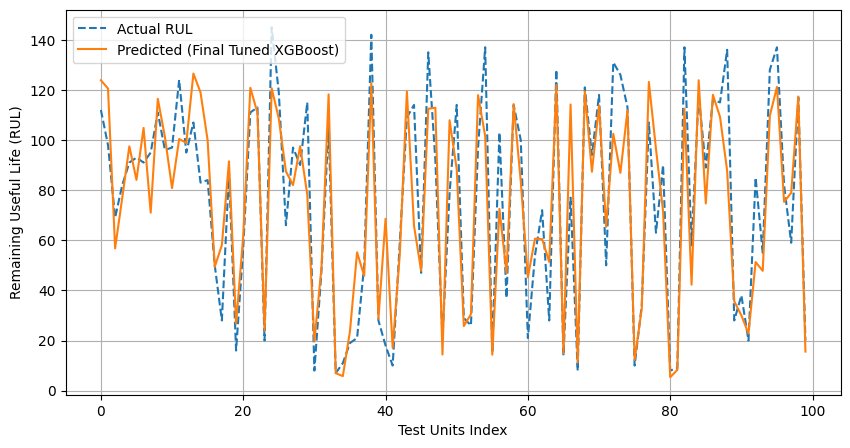

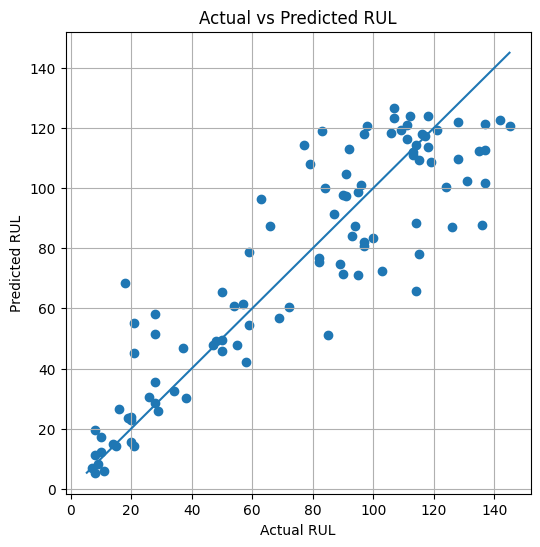

In [37]:
_ = evaluate_model_cv(
    best_model,
    X_train,
    y_train,
    X_test,
    y_true,
    "Final Tuned XGBoost"
)

In [38]:
importances = best_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feature_importance_df.head(20))

           feature  importance
10            Ps30    0.382070
0   time_in_cycles    0.160336
5              T50    0.157907
11             phi    0.086117
9               Nc    0.044914
13             NRc    0.032792
7              P30    0.024159
14             BPR    0.023879
8               Nf    0.014304
12             NRf    0.012866
3              T24    0.011997
16             W31    0.011707
15         htBleed    0.011516
17             W32    0.009606
4              T30    0.006640
1        setting_1    0.003221
2        setting_2    0.003041
6              P15    0.002928


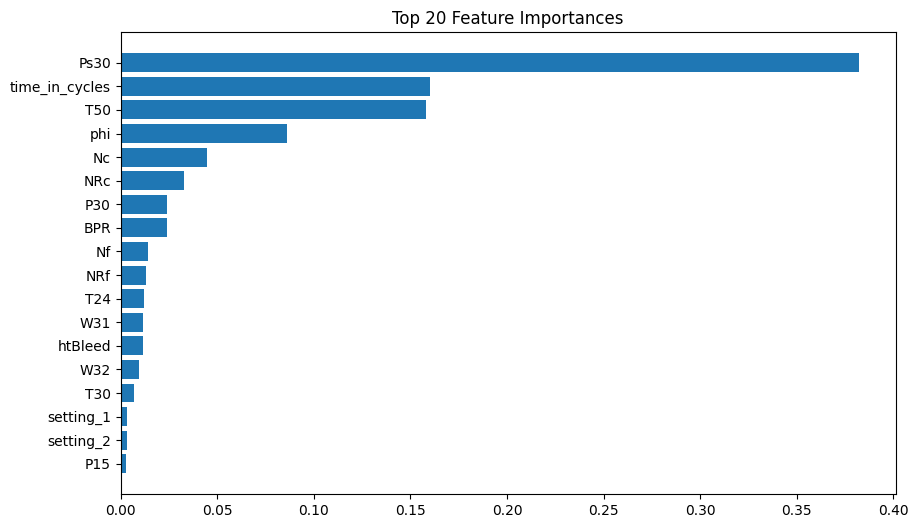

In [39]:
import matplotlib.pyplot as plt

top_n = 20
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(10,6))
plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances")
plt.show()

In [40]:
result = permutation_importance(
    best_model,
    X_test,
    y_true,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

print(perm_importance_df.head(20))

           feature  importance
0   time_in_cycles    0.132223
10            Ps30    0.065168
9               Nc    0.049626
13             NRc    0.032010
5              T50    0.027540
11             phi    0.022207
3              T24    0.018345
14             BPR    0.010084
7              P30    0.006561
17             W32    0.006273
12             NRf    0.005889
8               Nf    0.004580
4              T30    0.004403
16             W31    0.003481
15         htBleed    0.003239
6              P15    0.000000
2        setting_2   -0.000587
1        setting_1   -0.002576
